In [104]:
import pandas as pd
import numpy as np

In [105]:
csv_path = "../data/custom/orders.csv"
raw_csv_path = "../data/csv/Hackaton/Detalle_entrega.csv"
df = pd.read_csv(csv_path)

transport_col = "transport_id"
client_col = "client"
date_col = "date"
amount_col = "amount"
item_col = "item"
item_description_col = "item_description"
unit_col = "unit"

required_columns = {
    transport_col,
    client_col,
    date_col,
    amount_col,
    item_col,
    item_description_col,
    unit_col,
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in cleaned dataset: {sorted(missing_columns)}")

# Cleaned file can sometimes contain one client per transport_id,
# which collapses client co-occurrence graphs. In that case, recover
# route-level client identity from the raw dataset while keeping cleaned rows.
unique_clients_per_transport = df.groupby(transport_col)[client_col].nunique(dropna=True)
needs_client_recovery = (
    not unique_clients_per_transport.empty
    and unique_clients_per_transport.max() <= 1
)

if needs_client_recovery:
    raw_columns = [
        "FECHA",
        "Transporte",
        "Destinatario mcía.",
        "Nombre 1",
        "Material",
        "Cantidad entrega",
        "Un.medida venta",
    ]
    raw_df = pd.read_csv(raw_csv_path, usecols=raw_columns).rename(
        columns={
            "FECHA": date_col,
            "Transporte": transport_col,
            "Destinatario mcía.": "client_id",
            "Nombre 1": "client_name",
            "Material": item_col,
            "Cantidad entrega": amount_col,
            "Un.medida venta": unit_col,
        }
    )

    raw_df[unit_col] = raw_df[unit_col].astype(str).str.strip().str.lower()

    raw_df[amount_col] = pd.to_numeric(raw_df[amount_col], errors="coerce")
    raw_df = raw_df[raw_df[amount_col].notna()].copy()

    df[amount_col] = pd.to_numeric(df[amount_col], errors="coerce")

    merge_cols = [date_col, transport_col, item_col, amount_col, unit_col]
    for col in [date_col, transport_col, item_col, unit_col]:
        df[col] = df[col].astype(str).str.strip()
        raw_df[col] = raw_df[col].astype(str).str.strip()

    df["_match_seq"] = df.groupby(merge_cols).cumcount()
    raw_df["_match_seq"] = raw_df.groupby(merge_cols).cumcount()

    df = df.merge(
        raw_df[merge_cols + ["_match_seq", "client_id", "client_name"]],
        on=merge_cols + ["_match_seq"],
        how="left",
    )
    df = df.drop(columns=["_match_seq"])

    df["analysis_client"] = (
        df["client_name"].fillna(df["client_id"]).fillna(df[client_col]).astype(str).str.strip()
    )
    print("Recovered client identity from raw dataset for clustering analysis.")
else:
    df["analysis_client"] = df[client_col].astype(str).str.strip()

client_col = "analysis_client"

In [106]:
unique_transport_ids = sorted(df[transport_col].dropna().unique())

for transport_id in unique_transport_ids:
    df_transport = df[df[transport_col] == transport_id]

    unique_clients = sorted(df_transport[client_col].dropna().astype(str).unique())

    print(
        f"transport_id={transport_id} rows={len(df_transport)} unique_clients={len(unique_clients)}"
    )
    # Uncomment this line to see all unique client names for each transport id.
    # print(unique_clients)



transport_id=11420136 rows=3 unique_clients=1
transport_id=11420324 rows=3 unique_clients=2
transport_id=11420325 rows=7 unique_clients=1
transport_id=11420326 rows=9 unique_clients=1
transport_id=11420327 rows=7 unique_clients=1
transport_id=11420328 rows=66 unique_clients=4
transport_id=11420329 rows=65 unique_clients=4
transport_id=11420330 rows=5 unique_clients=1
transport_id=11420331 rows=24 unique_clients=3
transport_id=11420332 rows=54 unique_clients=6
transport_id=11420334 rows=24 unique_clients=5
transport_id=11420379 rows=53 unique_clients=8
transport_id=11420391 rows=14 unique_clients=3
transport_id=11420392 rows=6 unique_clients=1
transport_id=11420393 rows=134 unique_clients=14
transport_id=11420414 rows=64 unique_clients=9
transport_id=11420415 rows=117 unique_clients=3
transport_id=11420416 rows=125 unique_clients=9
transport_id=11420417 rows=32 unique_clients=6
transport_id=11420461 rows=117 unique_clients=13
transport_id=11420516 rows=2 unique_clients=1
transport_id=11

In [107]:
from collections import Counter
from itertools import combinations

# Count how often each pair of clients appears together in the same transport_id.
pair_counts = Counter()

for transport_id, df_transport in df.groupby(transport_col):
    clients = sorted(df_transport[client_col].dropna().astype(str).unique())

    # Only transport_ids with at least 2 unique clients can generate a pair.
    if len(clients) < 2:
        continue

    for pair in combinations(clients, 2):
        pair_counts[pair] += 1

pairs_df = (
    pd.DataFrame(
        [(c1, c2, cnt) for (c1, c2), cnt in pair_counts.items()],
        columns=["client_1", "client_2", "times_together"],
    )
    .sort_values("times_together", ascending=False)
    .reset_index(drop=True)
)

clients_with_company = set(pairs_df["client_1"]).union(set(pairs_df["client_2"]))

print(f"Clients delivered together with at least one other client: {len(clients_with_company)}")
print(f"Unique client pairs found: {len(pairs_df)}")
print(f"Total co-occurrence events: {pairs_df['times_together'].sum()}")

pairs_df.head(20)

Clients delivered together with at least one other client: 1171
Unique client pairs found: 24145
Total co-occurrence events: 48872


,client_1,client_2,times_together
0,CAFE DE LA CORONA,PA TONET,17
1,BONATAPA,Bar 20 PA K,17
2,BAR DE LA BENZINERA,BAR DE LA BENZINERA HIGIENE,17
3,BRUNCH 4.12 MUSIC,CAFETERIA ANGELA,17
4,RESTAURANT NOU PAMPLONA,RESTAURANT NOU PAMPLONA HIGIENE,16
5,BAR LOS GALLEGOS,LA PERGOLA,16
6,CAFE SANT ROC,PA TONET,16
7,CAFE DE LA CORONA,PURE COFFEE,16
8,CAFE DE LA CORONA,CAFE SANT ROC,16
9,BAR RESTAURANT PAVEPIC,BAR XARANA GRANOLLERS,15


In [108]:
# Count the most frequent clients and keep only top-X for clustering.
# Frequency here is number of deliveries (unique transport assignments) per client.
top_x_clients = 5000

client_frequency = (
    df[[client_col, transport_col]]
    .dropna(subset=[client_col, transport_col])
    .assign(
        **{
            client_col: lambda x: x[client_col].astype(str).str.strip(),
            transport_col: lambda x: x[transport_col].astype(str).str.strip(),
        }
    )
    .drop_duplicates(subset=[client_col, transport_col])
    .groupby(client_col)[transport_col]
    .count()
    .rename("deliveries")
)

pairs_df["freq_1"] = pairs_df["client_1"].map(client_frequency).fillna(0)
pairs_df["freq_2"] = pairs_df["client_2"].map(client_frequency).fillna(0)
pairs_df["min_client_freq"] = pairs_df[["freq_1", "freq_2"]].min(axis=1)
pairs_df["normalized_score"] = np.where(
    pairs_df["min_client_freq"] > 0,
    pairs_df["times_together"] / pairs_df["min_client_freq"],
    0.0,
)
pairs_df = pairs_df.sort_values("normalized_score", ascending=False).reset_index(drop=True)

top_clients = set(client_frequency.head(top_x_clients).index)

filtered_pairs_df = pairs_df[
    pairs_df["client_1"].isin(top_clients) & pairs_df["client_2"].isin(top_clients)
].copy()
filtered_pairs_df = filtered_pairs_df.sort_values("normalized_score", ascending=False).reset_index(drop=True)

print(f"Total unique clients: {client_frequency.shape[0]}")
print(f"Top-X selected clients: {len(top_clients)}")
print(f"Pairs kept after top-X filter: {len(filtered_pairs_df)}")

client_frequency.head(20)

Total unique clients: 1184
Top-X selected clients: 1184
Pairs kept after top-X filter: 24145


analysis_client
' EL NOU' TOÓ RICO                     6
(RESTAURANT) SPORT & HEALTH OXIGEN    13
2 PRINCIPE                             2
412 COFFEE BEER                       17
755_SUBLIME                            4
80'S SPIRIT                            2
903100 PLASTICOS TA-TAY                1
A VOCADOS                              9
AAVV SANTA ROSA                        1
AGROBOTIGA DE GALLECS                  1
AGROBOTIGA RODA, SL                   12
AIRE                                   4
AKI MISMO                             13
ALAIA COFFE BAR                        5
ALASKA BAR                             9
ALBA AUDIOVISUALS                      1
ALFREDO PARODI FURHMAN                 1
ALHAMBRA 57                            8
ALOE                                  13
ALORA                                 12
Name: deliveries, dtype: int64

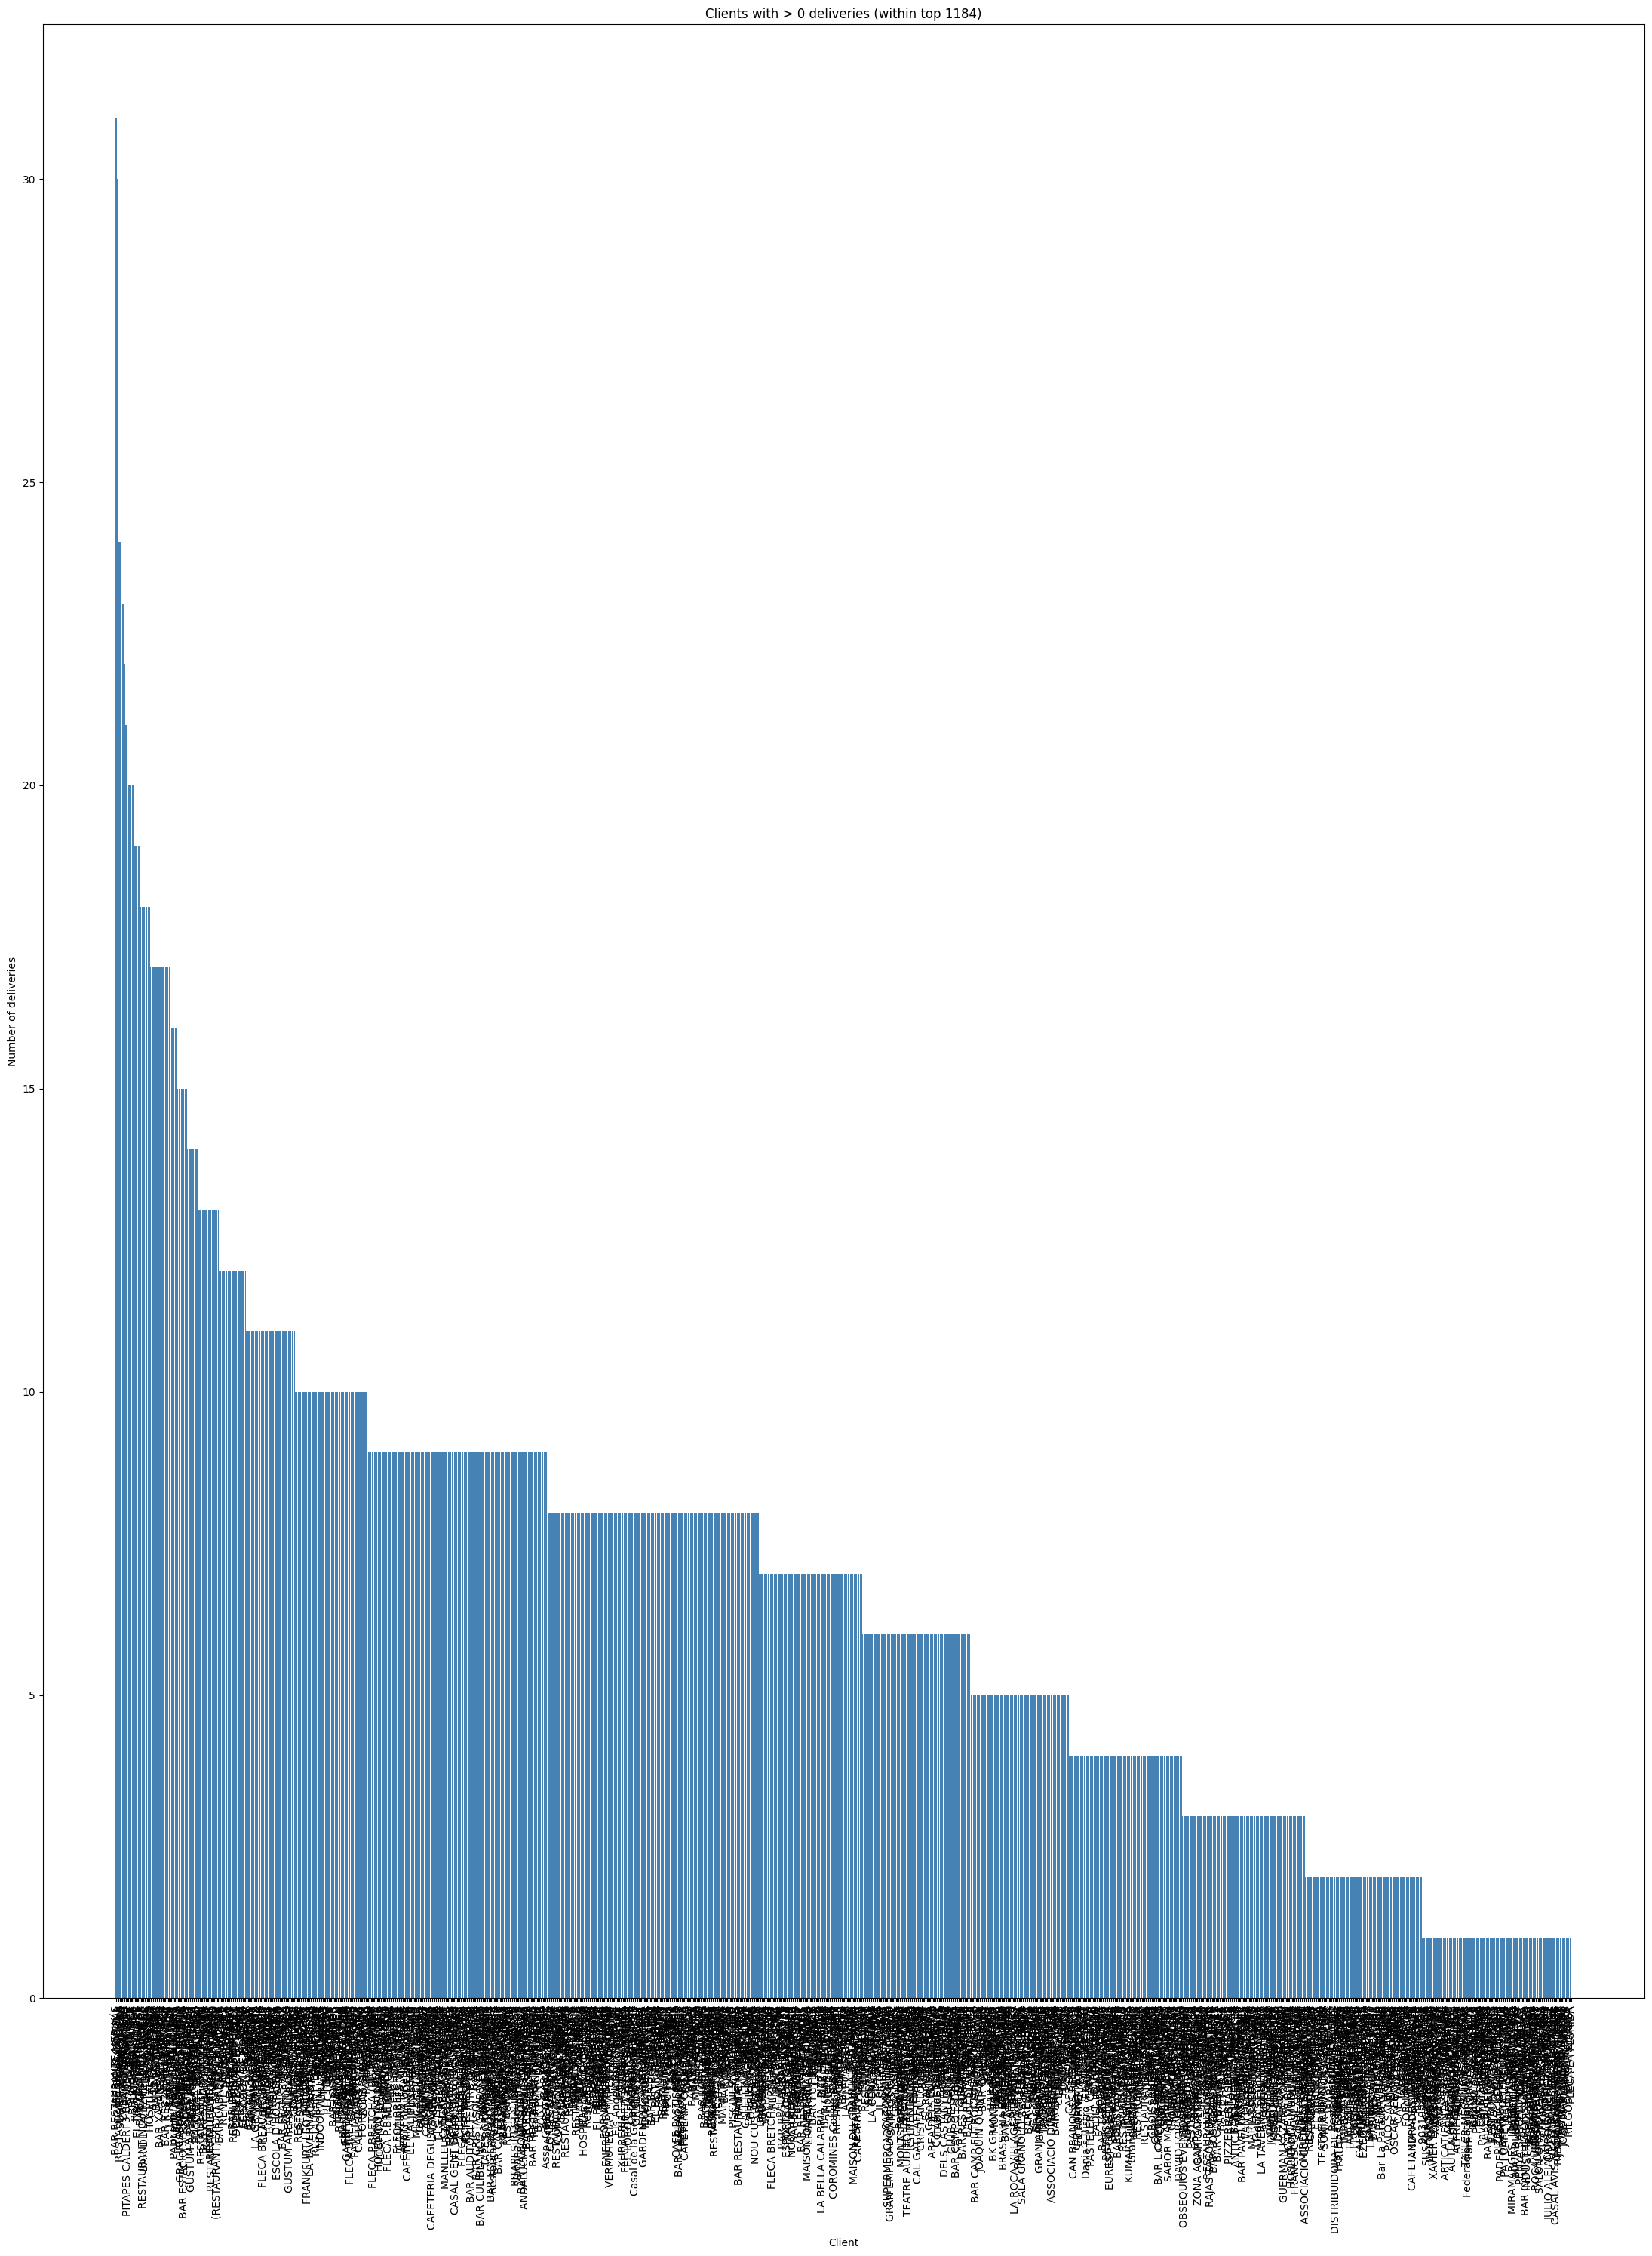

Pairs kept after top-X filter: 100.00%


In [109]:
import matplotlib.pyplot as plt

# Visualize frequent clients with client names on x-axis.
plot_n_clients = min(5000, len(client_frequency))
min_deliveries_for_plot = 0

top_clients_plot = (
    client_frequency.head(plot_n_clients)
    .loc[lambda s: s > min_deliveries_for_plot]
    .sort_values(ascending=False)
)

plt.figure(figsize=(22, 30))
plt.bar(top_clients_plot.index, top_clients_plot.values, color="steelblue")
plt.title(
    f"Clients with > {min_deliveries_for_plot} deliveries (within top {plot_n_clients})"
)
plt.xlabel("Client")
plt.ylabel("Number of deliveries")
plt.xticks(rotation=90, ha="center")
plt.tight_layout()
plt.show()

# Optional quick context: how much data is retained by top-X filtering.
pairs_kept_pct = (len(filtered_pairs_df) / len(pairs_df) * 100) if len(pairs_df) else 0
print(f"Pairs kept after top-X filter: {pairs_kept_pct:.2f}%")

In [110]:
# Greedy clustering with conditional cluster merges, using only filtered top-X clients.
# Rules:
# 1) If neither client is assigned -> create a new cluster with both.
# 2) If exactly one is assigned -> add the other to that same cluster.
# 3) If both are in different clusters -> merge only when merged size > 15.
# 4) Cluster size is capped at 30 after add/merge operations.
# 5) Otherwise -> invalid pair, skip.
min_normalized_score = 0.0
merge_if_size_gt = 15
max_cluster_size = 30

pairs_for_clustering = filtered_pairs_df[
    filtered_pairs_df["normalized_score"] >= min_normalized_score
].copy()
pairs_for_clustering = pairs_for_clustering.sort_values("normalized_score", ascending=False)

clusters = []
client_to_cluster = {}
invalid_matches = 0
merged_clusters = 0

for _, row in pairs_for_clustering.iterrows():
    c1 = row["client_1"]
    c2 = row["client_2"]

    cluster_idx_1 = client_to_cluster.get(c1)
    cluster_idx_2 = client_to_cluster.get(c2)

    if cluster_idx_1 is None and cluster_idx_2 is None:
        new_cluster = {c1, c2}
        clusters.append(new_cluster)
        new_idx = len(clusters) - 1
        client_to_cluster[c1] = new_idx
        client_to_cluster[c2] = new_idx

    elif cluster_idx_1 is not None and cluster_idx_2 is None:
        if len(clusters[cluster_idx_1]) < max_cluster_size:
            clusters[cluster_idx_1].add(c2)
            client_to_cluster[c2] = cluster_idx_1
        else:
            invalid_matches += 1

    elif cluster_idx_1 is None and cluster_idx_2 is not None:
        if len(clusters[cluster_idx_2]) < max_cluster_size:
            clusters[cluster_idx_2].add(c1)
            client_to_cluster[c1] = cluster_idx_2
        else:
            invalid_matches += 1

    else:
        if cluster_idx_1 == cluster_idx_2:
            invalid_matches += 1
            continue

        merged_cluster = clusters[cluster_idx_1] | clusters[cluster_idx_2]
        if len(merged_cluster) > merge_if_size_gt and len(merged_cluster) <= max_cluster_size:
            keep_idx = min(cluster_idx_1, cluster_idx_2)
            drop_idx = max(cluster_idx_1, cluster_idx_2)

            clusters[keep_idx] = merged_cluster
            clusters[drop_idx] = set()
            for client in merged_cluster:
                client_to_cluster[client] = keep_idx
            merged_clusters += 1
        else:
            invalid_matches += 1

# Add singleton clusters only for selected top clients not assigned in accepted pairs.
clustered_clients = set().union(*clusters) if clusters else set()
for client in sorted(top_clients - clustered_clients):
    clusters.append({client})

cluster_rows = [
    {
        "cluster_id": idx,
        "cluster_size": len(cluster),
        "members": sorted(cluster),
    }
    for idx, cluster in enumerate(clusters)
    if cluster
]

clusters_df = (
    pd.DataFrame(cluster_rows)
    .sort_values(["cluster_size", "cluster_id"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Total clusters (top-X universe): {len(clusters_df)}")
print(f"Largest cluster size: {clusters_df['cluster_size'].max()}")
print(f"Singleton clusters: {(clusters_df['cluster_size'] == 1).sum()}")
print(f"Cluster merges accepted (> {merge_if_size_gt} members): {merged_clusters}")
print(f"Max cluster size cap: {max_cluster_size}")
print(f"Invalid matches skipped: {invalid_matches}")

clusters_df.head(60)

Total clusters (top-X universe): 84
Largest cluster size: 30
Singleton clusters: 21
Cluster merges accepted (> 15 members): 104
Max cluster size cap: 30
Invalid matches skipped: 23045


,cluster_id,cluster_size,members
0,0,30,"[ATARASII, BAR CAPARROS, BAR LA LOLA, BAR LA V..."
1,1,30,"[BAR ARAMAN, BAR BUS STOP, BAR KUNDALINI, BAR ..."
2,2,30,"[2 PRINCIPE, ALOE, AREA TRUCK ( SHELL ), AURIA..."
3,3,30,"[ALBA AUDIOVISUALS, ATENEU ALIANÇA, BAR CA LA ..."
4,4,30,"[BAR CAN PLANOLES, BAR EL TROPEZON, BAR ESTACI..."
5,5,30,"[ANGEL BRUGUERA FONT, ANTIC FORN RIERA CENTELL..."
6,6,30,"[AIRE, AUTENTIK’S CAMPO DE FUTBOL, BAR CASAL C..."
7,7,30,"[BAR DE LA BENZINERA, BAR DE LA BENZINERA HIGI..."
8,12,30,"[ASSEMBLEA JOVE VIC, ASSOCIACIO CULTURAL SAGAL..."
9,13,30,"[AREA DELS PARDALS-GASOLI, AREA VIC BP, BAR CA..."


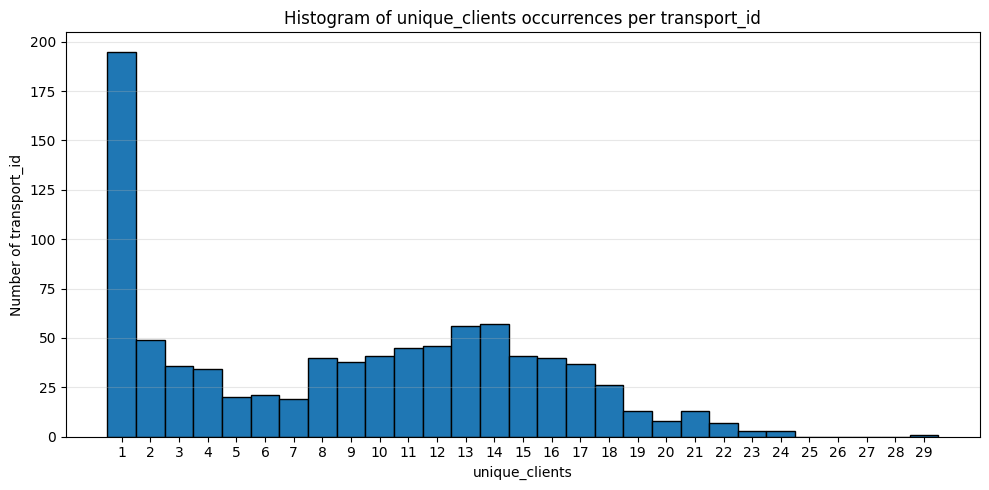

count    889.000000
mean       8.883015
std        6.322047
min        1.000000
25%        2.000000
50%        9.000000
75%       14.000000
max       29.000000
Name: unique_clients, dtype: float64

In [111]:
import matplotlib.pyplot as plt

# Number of unique clients per transport_id.
unique_clients_per_transport = (
    df.groupby(transport_col)[client_col]
    .nunique()
    .rename("unique_clients")
)

plt.figure(figsize=(10, 5))
plt.hist(
    unique_clients_per_transport,
    bins=range(1, unique_clients_per_transport.max() + 2),
    edgecolor="black",
    align="left",
)
plt.title("Histogram of unique_clients occurrences per transport_id")
plt.xlabel("unique_clients")
plt.ylabel("Number of transport_id")
plt.xticks(range(1, unique_clients_per_transport.max() + 1))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

unique_clients_per_transport.describe()

In [112]:
import html
import re
import unicodedata
from pathlib import Path

import folium


def normalize_text(value: object) -> str:
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    return " ".join(text.split())


# Build a client -> geocoded query map from the same raw source used to create addresses.
address_cols = ["Nombre 1", "Calle", "CP", "Población"]
address_df = pd.read_csv(raw_csv_path, usecols=address_cols, dtype=str)
address_df = address_df.rename(
    columns={"Nombre 1": "client_name", "Calle": "street", "CP": "cp", "Población": "city"}
)

for col in ["client_name", "street", "cp", "city"]:
    address_df[col] = address_df[col].fillna("").astype(str).str.strip()

address_df = address_df[
    (address_df["client_name"] != "")
    & (address_df["street"] != "")
    & (address_df["cp"] != "")
    & (address_df["city"] != "")
].copy()

address_df["client_norm"] = address_df["client_name"].map(normalize_text)
address_df["query"] = (
    address_df["street"] + ", " + address_df["cp"] + " " + address_df["city"] + ", Spain"
)

# Keep the most frequent query per client.
client_query_map = (
    address_df.groupby(["client_norm", "query"], as_index=False)
    .size()
    .sort_values(["client_norm", "size"], ascending=[True, False])
    .drop_duplicates(subset=["client_norm"])
    [["client_norm", "query"]]
)

# Expand cluster members to one row per client member.
members_df = (
    clusters_df[["cluster_id", "cluster_size", "members"]]
    .explode("members")
    .rename(columns={"members": "client_name"})
)
members_df["client_norm"] = members_df["client_name"].map(normalize_text)
members_df = members_df.merge(client_query_map, on="client_norm", how="left")

geo_candidate_paths = [
    Path("../custom/geo/geocoded_direcciones.csv"),
    Path("custom/geo/geocoded_direcciones.csv"),
    Path("../data/custom/geo/geocoded_direcciones.csv"),
    Path("data/custom/geo/geocoded_direcciones.csv"),
]
geo_csv_path = next((p for p in geo_candidate_paths if p.exists()), None)
if geo_csv_path is None:
    raise FileNotFoundError(
        "Could not find geocoded_direcciones.csv. Checked: "
        + ", ".join(str(p) for p in geo_candidate_paths)
    )

geo_df = pd.read_csv(geo_csv_path, engine="python", on_bad_lines="skip")
required_geo_cols = {"query", "lat", "lon"}
missing_geo_cols = required_geo_cols - set(geo_df.columns)
if missing_geo_cols:
    raise ValueError(f"Missing columns in {geo_csv_path}: {sorted(missing_geo_cols)}")

geo_df = geo_df.dropna(subset=["query", "lat", "lon"]).copy()
geo_df["lat"] = pd.to_numeric(geo_df["lat"], errors="coerce")
geo_df["lon"] = pd.to_numeric(geo_df["lon"], errors="coerce")
geo_df = geo_df.dropna(subset=["lat", "lon"])
geo_df["query_norm"] = geo_df["query"].fillna("").astype(str).map(normalize_text)
geo_df = geo_df.drop_duplicates(subset=["query_norm"])

members_df["query_norm"] = members_df["query"].fillna("").astype(str).map(normalize_text)
map_df = members_df.merge(
    geo_df[["query_norm", "lat", "lon"]],
    on="query_norm",
    how="left",
)

missing_geo = map_df["lat"].isna().sum()
map_df = map_df.dropna(subset=["lat", "lon"]).copy()
if map_df.empty:
    raise ValueError("No cluster members could be matched to geocoded coordinates.")

output_dir = Path("cluster_map")
output_dir.mkdir(parents=True, exist_ok=True)

cluster_summaries = []
for cluster_id, selected_df in map_df.groupby("cluster_id", sort=True):
    selected_df = selected_df.copy()
    if selected_df.empty:
        continue

    center_lat = selected_df["lat"].median()
    center_lon = selected_df["lon"].median()

    cluster_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=11,
        tiles="CartoDB Positron",
    )

    for row in selected_df.itertuples(index=False):
        popup_text = (
            f"Client: {html.escape(str(row.client_name))}<br>"
            f"Cluster ID: {int(row.cluster_id)}<br>"
            f"Cluster size: {int(row.cluster_size)}<br>"
            f"Address: {html.escape(str(row.query))}"
        )
        folium.CircleMarker(
            location=[row.lat, row.lon],
            radius=7,
            weight=2,
            color="#2563EB",
            fill=True,
            fill_color="#2563EB",
            fill_opacity=0.85,
            opacity=1.0,
            popup=folium.Popup(popup_text, max_width=420),
            tooltip=f"{row.client_name} (cluster {int(cluster_id)})",
        ).add_to(cluster_map)

    output_path = output_dir / f"cluster_{int(cluster_id):03d}.html"
    cluster_map.save(output_path)

    cluster_summaries.append(
        {
            "cluster_id": int(cluster_id),
            "mapped_points": int(len(selected_df)),
            "output_path": str(output_path),
        }
    )

summary_df = pd.DataFrame(cluster_summaries).sort_values("cluster_id").reset_index(drop=True)

mapped_clusters = set(map_df["cluster_id"].dropna().tolist())
all_clusters = set(clusters_df["cluster_id"].dropna().tolist())
missing_clusters = sorted(all_clusters - mapped_clusters)

print(f"Cluster members total: {len(members_df):,}")
print(f"Mapped to coordinates: {len(map_df):,}")
print(f"Missing coordinates: {missing_geo:,}")
print(f"Generated standalone cluster maps: {len(cluster_summaries):,}")
print(f"Clusters without mapped coordinates: {len(missing_clusters):,}")
if missing_clusters:
    print(f"First missing cluster IDs: {missing_clusters[:15]}")
print(f"Output folder: {output_dir.resolve()}")

summary_df

Cluster members total: 1,184
Mapped to coordinates: 1,166
Missing coordinates: 18
Generated standalone cluster maps: 84
Clusters without mapped coordinates: 0
Output folder: /Users/luka.papez/Code/personal/damm-hackathon/notebooks/cluster_map


,cluster_id,mapped_points,output_path
0,0,30,cluster_map/cluster_000.html
1,1,30,cluster_map/cluster_001.html
2,2,30,cluster_map/cluster_002.html
3,3,30,cluster_map/cluster_003.html
4,4,30,cluster_map/cluster_004.html
...,...,...,...
79,183,1,cluster_map/cluster_183.html
80,184,1,cluster_map/cluster_184.html
81,185,1,cluster_map/cluster_185.html
82,186,1,cluster_map/cluster_186.html


In [113]:
import json
from pathlib import Path

cluster_source = "normalized"

data_custom_dir = next(
    (path for path in [Path("../data/custom"), Path("data/custom")] if path.exists()),
    Path("../data/custom"),
)
output_dir = data_custom_dir / "clustering" / cluster_source
output_dir.mkdir(parents=True, exist_ok=True)

clusters_export_df = clusters_df.copy()
clusters_export_df["members_json"] = clusters_export_df["members"].map(
    lambda members: json.dumps(list(members), ensure_ascii=False)
)
clusters_export_df = clusters_export_df[["cluster_id", "cluster_size", "members_json"]]

cluster_lookup_df = (
    clusters_df[["cluster_id", "cluster_size", "members"]]
    .explode("members")
    .rename(columns={"members": "client_name"})
    .dropna(subset=["client_name"])
    .reset_index(drop=True)
)
cluster_lookup_df["client_name"] = cluster_lookup_df["client_name"].astype(str).str.strip()
cluster_lookup_df = cluster_lookup_df[cluster_lookup_df["client_name"] != ""].copy()
cluster_lookup_df["cluster_source"] = cluster_source

clusters_path = output_dir / "clusters.csv"
lookup_path = output_dir / "client_cluster_lookup.csv"
clusters_export_df.to_csv(clusters_path, index=False)
cluster_lookup_df.to_csv(lookup_path, index=False)

print(f"Exported clusters: {len(clusters_export_df):,} rows -> {clusters_path.resolve()}")
print(f"Exported client lookup: {len(cluster_lookup_df):,} rows -> {lookup_path.resolve()}")

cluster_lookup_df.head()

Exported clusters: 84 rows -> /Users/luka.papez/Code/personal/damm-hackathon/data/custom/clustering/normalized/clusters.csv
Exported client lookup: 1,184 rows -> /Users/luka.papez/Code/personal/damm-hackathon/data/custom/clustering/normalized/client_cluster_lookup.csv


,cluster_id,cluster_size,client_name,cluster_source
0,0,30,ATARASII,normalized
1,0,30,BAR CAPARROS,normalized
2,0,30,BAR LA LOLA,normalized
3,0,30,BAR LA VERMUTERIA,normalized
4,0,30,BAR MERCADO,normalized
